In [1]:
import warnings
import numpy as np
from scipy import signal

import matplotlib.pyplot as plt
from matplotlib import rcParams as rc
configs = {
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    # 'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Arial', 'Liberation Sans', 'sans-serif'],
    'font.sans-serif': ['Palatino', 'Microsoft YaHei', 'SimHei', 'Arial', 'Liberation Sans', 'sans-serif'],
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'mathtext.fontset': "cm",
    # 'mathtext.rm': "asana math",
    # 'mathtext.cal': "asana math",
    "font.size": 16,
    # 'axes.labelsize': 'large',
    # 'axes.labelpad': 8.0,
    # 'xtick.major.pad': 9.0,
}
rc.update(configs)
import os

import matplotlib.font_manager
font_path = "/home/nanxi/.local/share/fonts/Palatino-Linotype-Regular.ttf"
if os.path.exists(font_path):
    matplotlib.font_manager.fontManager.addfont(font_path)
    prop = matplotlib.font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    print(f"Set font to {prop.get_name()}")

Set font to Palatino Linotype


In [2]:
import os
import sys
os.chdir("../")
from scripts.validate_nonstationary import *
%matplotlib inline

In [3]:
from types import SimpleNamespace

args = SimpleNamespace(
    n_points=100,
    n_freqs=1024,
    n_realizations=16,
    point_index=0,
    window_size=64,
    overlap=50,
    w_up=5.0,
    component="u",
    mode="chunked-vmap",
    max_memory_gb=8.0,
    freq_batch_size=None,
    time_batch_size=None,
    modulation_amplitude=0.5,
    skip_low_freq_bins=1,
    variance_low_freq_bins=2,
    show=False,
    psd_snapshot_count=6,
    psd_snapshot_times=None
    
)

In [4]:

simulator = JaxNonstationaryWindSimulator(key=42, spectrum_type="kaimal-nd")
simulator.update_parameters(
    U_d=20.0,
    H_bar=0.0,
    alpha_0=0.12,
    z_0=0.01,
    w_up=args.w_up,
    N=args.n_freqs,
    M=args.n_freqs * 2,
)

positions = build_positions(args.n_points)
wind_speeds = jnp.full((args.n_points,), 20.0, dtype=jnp.float32)
dt = simulator.params["dt"]
times = np.asarray(jnp.arange(simulator.params["M"]) * dt)
modulation_values = 1.0 + args.modulation_amplitude * np.sin(2 * np.pi * times / simulator.params["T"])
target_freqs = np.asarray(simulator.calculate_simulation_frequency(simulator.params["N"], simulator.params["dw"]))
logging.info("Building target PSD from evolutional PSD generator")
target_psd_full = compute_theoretical_evolutional_psd(
    simulator,
    target_freqs,
    positions,
    wind_speeds,
    args.component,
    times,
    modulation_amplitude=args.modulation_amplitude,
    modulation_values=modulation_values,
)

realization_spectra = []
realization_variances = []
representative_signal = None
run_start = time.time()
for realization_idx in range(args.n_realizations):
    logging.info("Simulating realization %d/%d", realization_idx + 1, args.n_realizations)
    samples, _ = simulator.simulate_wind_nonstationary(
        positions,
        wind_speeds,
        component=args.component,
        mode=args.mode,
        modulation_amplitude=args.modulation_amplitude,
        modulation_values=modulation_values,
        max_memory_gb=args.max_memory_gb,
        freq_batch_size=args.freq_batch_size,
        time_batch_size=args.time_batch_size,
        auto_batch=True,
    )
    signal = np.asarray(samples[args.point_index])
    if representative_signal is None:
        representative_signal = signal.copy()
    estimate_freqs, estimate_times, spectrogram = compute_local_spectrogram(
        signal,
        dt,
        args.window_size,
        args.overlap,
    )
    realization_spectra.append(spectrogram)
    realization_variances.append(compute_windowed_variance(signal, args.window_size, args.overlap))

estimated_psd = np.mean(np.stack(realization_spectra, axis=0), axis=0)
estimated_variance = np.mean(np.stack(realization_variances, axis=0), axis=0)

point_target_psd = target_psd_full[:, :, args.point_index]
target_psd_windowed = average_target_over_windows(point_target_psd, times, estimate_times, dt, args.window_size)
target_psd_resampled = average_target_over_frequency_bands(target_freqs, target_psd_windowed, estimate_freqs)
target_psd_for_comparison = target_psd_resampled.T
snapshot_indices = select_snapshot_indices(estimate_times, args.psd_snapshot_count, args.psd_snapshot_times)
snapshot_times = estimate_times[snapshot_indices]
snapshot_estimated_psd = estimated_psd[:, snapshot_indices]
snapshot_target_psd = sample_theoretical_psd_at_times(point_target_psd, times, snapshot_times)
snapshot_target_resampled = average_target_over_frequency_bands(target_freqs, snapshot_target_psd, estimate_freqs)
target_variance = compute_target_windowed_variance(
    target_freqs,
    target_psd_windowed,
    dt,
    args.window_size,
)


INFO:2026-05-05 01:58:16,232:jax._src.xla_bridge:867: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-05-05 01:58:16,232 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-05-05 01:58:16,914 - INFO - Building target PSD from evolutional PSD generator
2026-05-05 01:58:18,261 - INFO - Simulating realization 1/16


Estimated nonstationary full-vmap memory: 710.16 GB
Using nonstationary batching with freq_batch_size=108, time_batch_size=218 (10 x 10 chunks, ~7.97 GB/chunk)
First nonstationary chunk completed (includes JIT compilation): 0.477 s
Tenth nonstationary chunk completed (steady-state compute): 0.964 s


2026-05-05 01:58:21,846 - INFO - Simulating realization 2/16


Total nonstationary simulation time: 3.108 s
Estimated nonstationary full-vmap memory: 710.16 GB
Using nonstationary batching with freq_batch_size=108, time_batch_size=218 (10 x 10 chunks, ~7.97 GB/chunk)
First nonstationary chunk completed (includes JIT compilation): 0.252 s
Tenth nonstationary chunk completed (steady-state compute): 0.600 s


2026-05-05 01:58:24,379 - INFO - Simulating realization 3/16


...

Total nonstationary simulation time: 2.498 s
Estimated nonstationary full-vmap memory: 710.16 GB
Using nonstationary batching with freq_batch_size=108, time_batch_size=218 (10 x 10 chunks, ~7.97 GB/chunk)
First nonstationary chunk completed (includes JIT compilation): 0.280 s
Tenth nonstationary chunk completed (steady-state compute): 0.616 s


2026-05-05 01:58:54,655 - INFO - Simulating realization 15/16


Total nonstationary simulation time: 2.529 s
Estimated nonstationary full-vmap memory: 710.16 GB
Using nonstationary batching with freq_batch_size=108, time_batch_size=218 (10 x 10 chunks, ~7.97 GB/chunk)
First nonstationary chunk completed (includes JIT compilation): 0.248 s
Tenth nonstationary chunk completed (steady-state compute): 0.594 s


2026-05-05 01:58:57,171 - INFO - Simulating realization 16/16


Total nonstationary simulation time: 2.508 s
Estimated nonstationary full-vmap memory: 710.16 GB
Using nonstationary batching with freq_batch_size=108, time_batch_size=218 (10 x 10 chunks, ~7.97 GB/chunk)
First nonstationary chunk completed (includes JIT compilation): 0.248 s
Tenth nonstationary chunk completed (steady-state compute): 0.594 s
Total nonstationary simulation time: 2.511 s


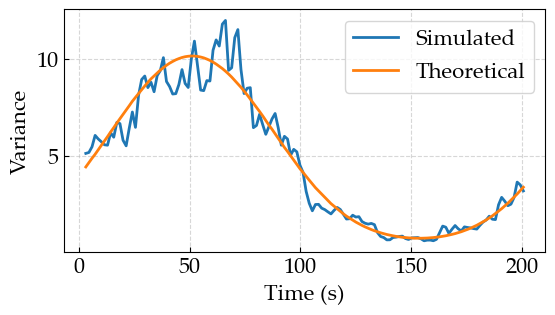

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
# plot the variance comparison

ax.plot(estimate_times, estimated_variance, label="Simulated", lw=2)
ax.plot(estimate_times, target_variance, label="Theoretical",  lw=2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Variance")
ax.legend()
fig.tight_layout()
fig.savefig("./img/validate_nonstationary_variance_comparison.png", dpi=300, bbox_inches="tight", pad_inches=0.1, )
fig.savefig("./img/validate_nonstationary_variance_comparison.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1, )


In [9]:
# plot total wind-speed histories at selected locations
selected_indices = [0, 50, 99]

base_wind_speeds = np.asarray(wind_speeds, dtype=np.float64)
total_wind_samples = np.asarray(samples, dtype=np.float64) + modulation_values[None, :] * base_wind_speeds[:, None]

selected_total_wind = total_wind_samples[selected_indices]
selected_x_positions = np.asarray(positions)[selected_indices, 0]

selected_indices, selected_x_positions

([0, 50, 99], array([   0.    ,  505.0505, 1000.    ], dtype=float32))

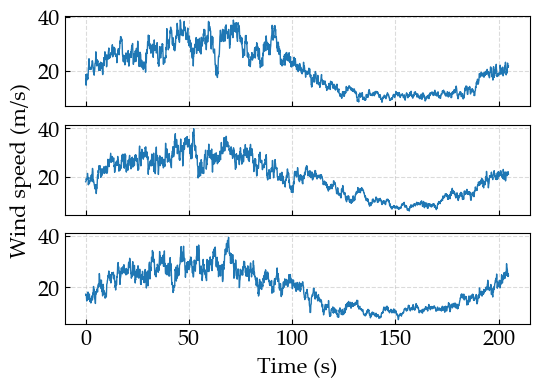

In [21]:
fig, axes = plt.subplots(len(selected_indices), 1, figsize=(6, 4), sharex=True)
axes = np.atleast_1d(axes)

colors = plt.cm.cividis(np.linspace(0.15, 0.85, len(selected_indices)))
for ax, idx, x_pos, total_wind, color in zip(axes, selected_indices, selected_x_positions, selected_total_wind, colors):
    ax.plot(times, total_wind, lw=1)
    # 
    # ax.set_title(rf"Point {idx} at $x = {x_pos:.1f}\ \mathrm{{m}}$")
    ax.grid(True, linestyle="--", alpha=0.45)
axes[1].set_ylabel("Wind speed (m/s)")
axes[-1].set_xlabel("Time (s)")
# fig.tight_layout()
fig.savefig("./img/validate_nonstationary_selected_wind_histories.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
fig.savefig("./img/validate_nonstationary_selected_wind_histories.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

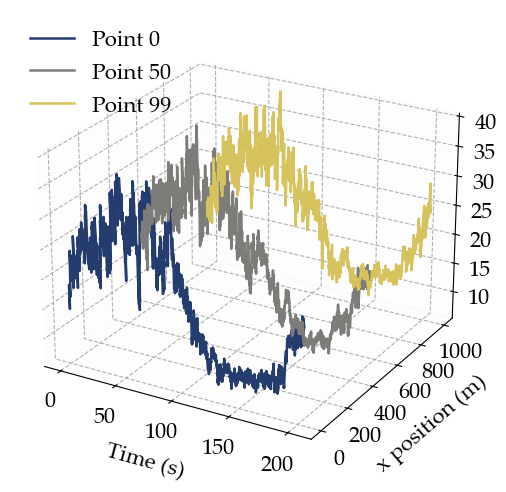

In [15]:
fig = plt.figure(figsize=(8.4, 5.2))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.cividis(np.linspace(0.15, 0.85, len(selected_indices)))
for idx, x_pos, total_wind, color in zip(selected_indices, selected_x_positions, selected_total_wind, colors):
    ax.plot(times, np.full_like(times, x_pos), total_wind, color=color, lw=1.8, label=f"Point {idx}")

ax.set_xlabel("Time (s)", labelpad=10)
ax.set_ylabel("x position (m)", labelpad=10)
ax.set_zlabel("Wind speed (m/s)", labelpad=10)
ax.view_init(elev=24, azim=-60)
ax.xaxis.pane.set_alpha(0.08)
ax.yaxis.pane.set_alpha(0.08)
ax.zaxis.pane.set_alpha(0.08)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
# fig.savefig("./img/validate_nonstationary_selected_wind_histories_3d.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
# fig.savefig("./img/validate_nonstationary_selected_wind_histories_3d.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

In [16]:
# prepare PSD snapshot curves in dimensional and non-dimensional forms
point_height = float(np.asarray(positions)[args.point_index, 2])
base_mean_speed = float(np.asarray(wind_speeds)[args.point_index])
snapshot_time_indices = [int(np.argmin(np.abs(times - time_value))) for time_value in snapshot_times]

snapshot_mean_speeds = np.array(
    [base_mean_speed * modulation_values[time_idx] for time_idx in snapshot_time_indices],
    dtype=np.float64,
 )

snapshot_friction_velocities = np.asarray(
    simulator.spectrum.calculate_friction_velocity(
        jnp.full((len(snapshot_times),), point_height, dtype=jnp.float32),
        jnp.asarray(snapshot_mean_speeds, dtype=jnp.float32),
        simulator.params["z_0"],
        simulator.params["z_d"],
        simulator.params["K"],
        simulator.params["alpha_0"],
    )
 )

plot_freqs = estimate_freqs[args.skip_low_freq_bins:]
snapshot_plot_data = []
for snapshot_idx, time_value in enumerate(snapshot_times):
    simulated_curve = snapshot_estimated_psd[args.skip_low_freq_bins:, snapshot_idx]
    theoretical_curve = snapshot_target_resampled[snapshot_idx, args.skip_low_freq_bins:]

    mean_speed = float(snapshot_mean_speeds[snapshot_idx])
    friction_velocity = float(snapshot_friction_velocities[snapshot_idx])

    nondim_frequency = plot_freqs * point_height / mean_speed
    simulated_curve_nondim = simulated_curve * mean_speed / (friction_velocity ** 2)
    theoretical_curve_nondim = theoretical_curve * mean_speed / (friction_velocity ** 2)

    snapshot_plot_data.append(
        {
            "time": float(time_value),
            "mean_speed": mean_speed,
            "friction_velocity": friction_velocity,
            "freqs": plot_freqs,
            "simulated_psd": simulated_curve,
            "theoretical_psd": theoretical_curve,
            "freqs_nondim": nondim_frequency,
            "simulated_psd_nondim": simulated_curve_nondim,
            "theoretical_psd_nondim": theoretical_curve_nondim,
        }
    )

snapshot_plot_data[:1]

[{'time': 3.2,
  'mean_speed': 20.98017120361328,
  'friction_velocity': 1.214437484741211,
  'freqs': array([0.15625, 0.3125 , 0.46875, 0.625  , 0.78125, 0.9375 , 1.09375,
         1.25   , 1.40625, 1.5625 , 1.71875, 1.875  , 2.03125, 2.1875 ,
         2.34375, 2.5    , 2.65625, 2.8125 , 2.96875, 3.125  , 3.28125,
         3.4375 , 3.59375, 3.75   , 3.90625, 4.0625 , 4.21875, 4.375  ,
         4.53125, 4.6875 , 4.84375, 5.     ]),
  'simulated_psd': array([8.50804   , 6.2790294 , 2.271062  , 1.2376603 , 0.88066703,
         0.72699475, 0.6438244 , 0.5501726 , 0.4918057 , 0.46221587,
         0.36793146, 0.17011881, 0.19336466, 0.17516291, 0.12153598,
         0.1318708 , 0.08568309, 0.07056855, 0.13879521, 0.09367939,
         0.0780013 , 0.08422011, 0.06785055, 0.05094875, 0.07357885,
         0.0660781 , 0.06797585, 0.06163624, 0.05012117, 0.04609747,
         0.04215068, 0.01918837], dtype=float32),
  'theoretical_psd': array([11.51024   ,  4.024109  ,  2.1500423 ,  1.3685442 ,  0.

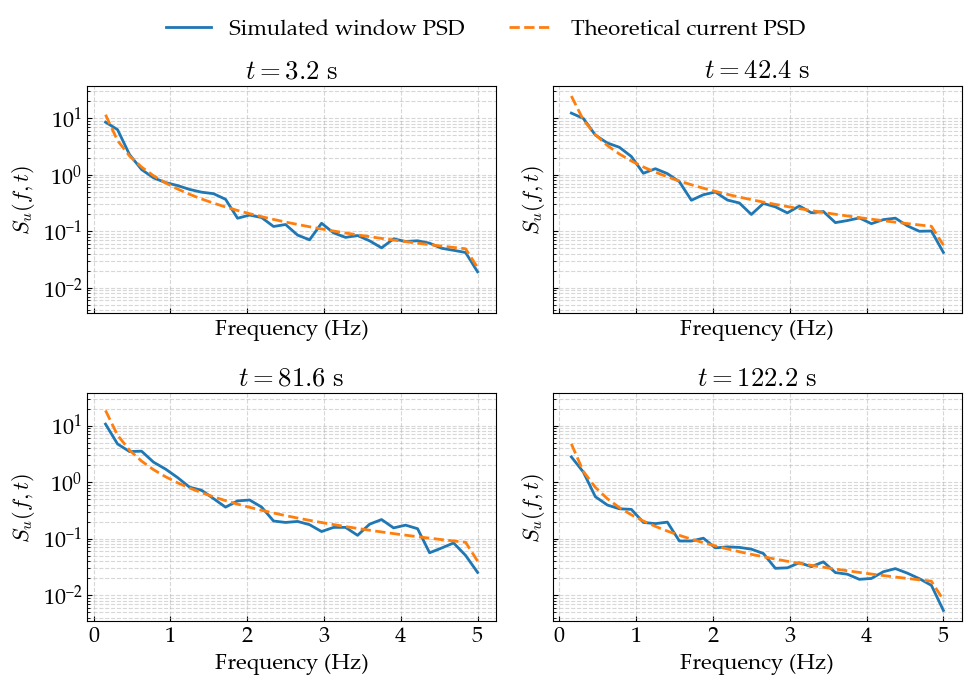

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, snapshot in zip(axes, snapshot_plot_data):
    ax.plot(
        snapshot["freqs"],
        snapshot["simulated_psd"],
        lw=2,
        label="Simulated window PSD",
    )
    ax.plot(
        snapshot["freqs"],
        snapshot["theoretical_psd"],
        "--",
        lw=2,
        label="Theoretical current PSD",
    )
    ax.set_title(rf"$t = {snapshot['time']:.1f}\ \mathrm{{s}}$")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(r"$S_u(f,t)$")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes[len(snapshot_plot_data):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.95))
# fig.savefig("./img/validate_nonstationary_psd_snapshots.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
# fig.savefig("./img/validate_nonstationary_psd_snapshots.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

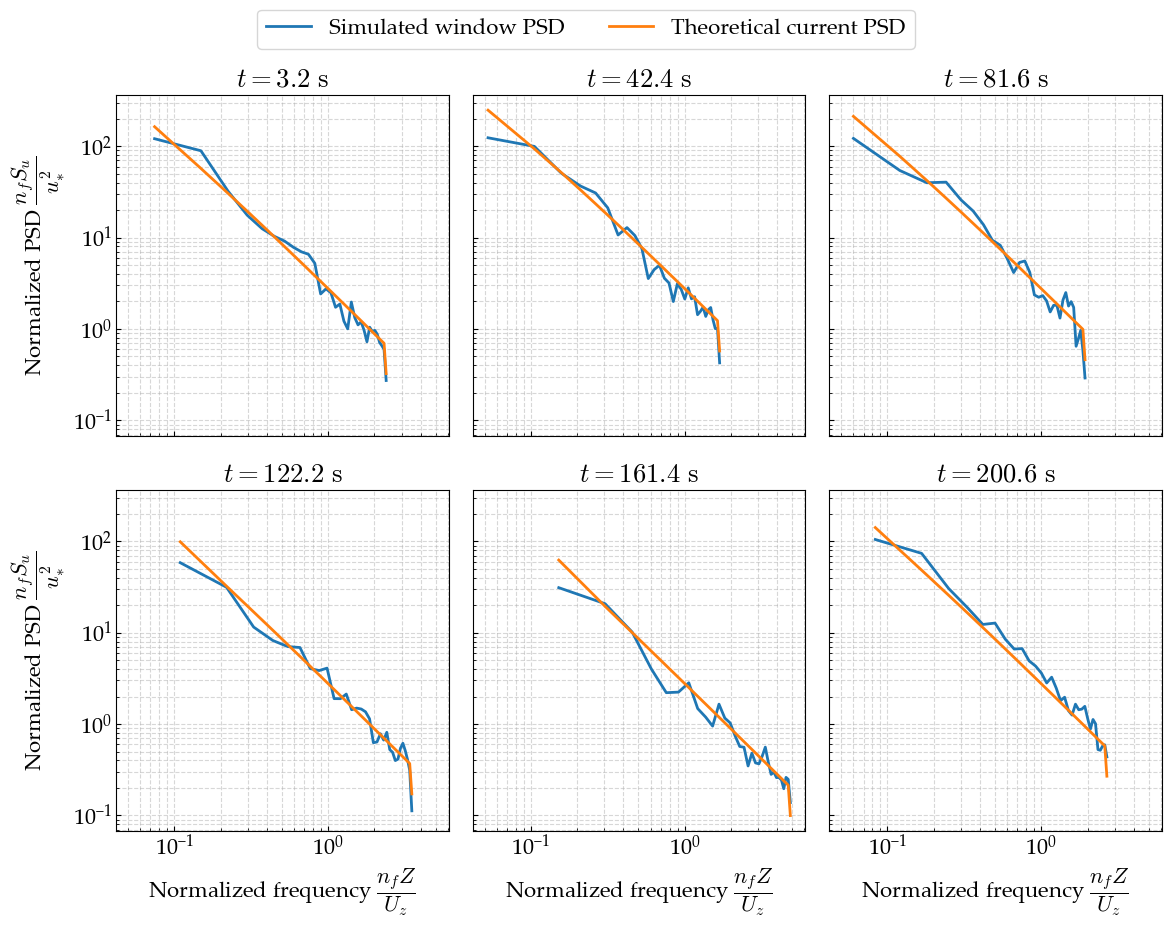

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(12, 9), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for idx, ax, snapshot in zip(range(len(axes)), axes, snapshot_plot_data):
    ax.plot(
        snapshot["freqs_nondim"],
        snapshot["simulated_psd_nondim"],
        lw=2,
        label="Simulated window PSD",
    )
    ax.plot(
        snapshot["freqs_nondim"],
        snapshot["theoretical_psd_nondim"],
        lw=2,
        label="Theoretical current PSD",
    )
    ax.set_title(rf"$t = {snapshot['time']:.1f}\ \mathrm{{s}}$")
    
    if idx % 3 == 0:
        # ax.set_ylabel("Power Spectral Density (m$^2$/s)")
        
        y_notation = r"$\dfrac{n_fS_u}{u_{*}^2}$"
        ax.set_ylabel("Normalized PSD " + y_notation)
    if idx >= 3:
        x_notation = r"$\dfrac{n_fZ}{U_z}$"
        ax.set_xlabel("Normalized frequency " + x_notation,)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes[len(snapshot_plot_data):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.98), )
fig.tight_layout()
fig.savefig("./img/validate_nonstationary_psd_snapshots_nondimensional.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
fig.savefig("./img/validate_nonstationary_psd_snapshots_nondimensional.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

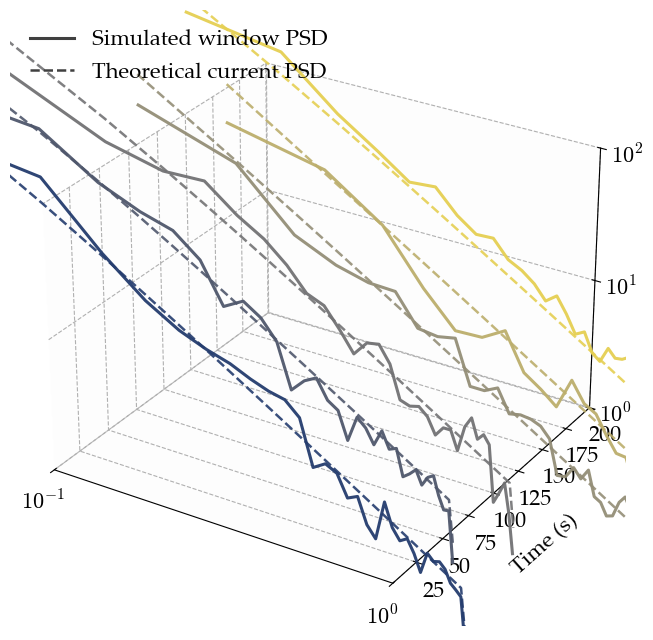

In [23]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

time_values = np.array([snapshot["time"] for snapshot in snapshot_plot_data], dtype=np.float64)
time_min = float(time_values.min())
time_max = float(time_values.max())
color_positions = np.linspace(0.15, 0.9, len(snapshot_plot_data))
colors = plt.cm.cividis(color_positions)

all_freqs_nondim = np.concatenate([snapshot["freqs_nondim"] for snapshot in snapshot_plot_data])
all_psd_nondim = np.concatenate(
    [
        snapshot["simulated_psd_nondim"] for snapshot in snapshot_plot_data
    ] + [
        snapshot["theoretical_psd_nondim"] for snapshot in snapshot_plot_data
    ]
 )

freq_floor = max(1e-4, float(np.min(all_freqs_nondim[all_freqs_nondim > 0.0])))
psd_floor = max(1e-4, float(np.min(all_psd_nondim[all_psd_nondim > 0.0])))

for color, snapshot in zip(colors, snapshot_plot_data):
    freqs_nondim = np.maximum(snapshot["freqs_nondim"], freq_floor)
    simulated_psd_nondim = np.maximum(snapshot["simulated_psd_nondim"], psd_floor)
    theoretical_psd_nondim = np.maximum(snapshot["theoretical_psd_nondim"], psd_floor)

    y_coords = np.full_like(freqs_nondim, snapshot["time"], dtype=np.float64)
    x_coords = np.log10(freqs_nondim)
    z_sim = np.log10(simulated_psd_nondim)
    z_theory = np.log10(theoretical_psd_nondim)

    ax.plot(
        x_coords,
        y_coords,
        z_sim,
        color=color,
        lw=2.2,
        alpha=0.95,
    )
    ax.plot(
        x_coords,
        y_coords,
        z_theory,
        color=color,
        lw=1.8,
        linestyle="--",
        alpha=0.9,
    )

freq_tick_values = np.array([1e-2, 1e-1, 1e0], dtype=np.float64)
freq_tick_values = freq_tick_values[(freq_tick_values >= freq_floor) & (freq_tick_values <= np.max(all_freqs_nondim))]
if freq_tick_values.size == 0:
    freq_tick_values = np.geomspace(freq_floor, np.max(all_freqs_nondim), 3)

psd_tick_values = np.array([1e-1, 1e0, 1e1, 1e2], dtype=np.float64)
psd_tick_values = psd_tick_values[(psd_tick_values >= psd_floor) & (psd_tick_values <= np.max(all_psd_nondim))]
if psd_tick_values.size == 0:
    psd_tick_values = np.geomspace(psd_floor, np.max(all_psd_nondim), 4)

ax.set_ylim(time_min, time_max)
ax.set_xlim(np.log10(freq_tick_values[0]), np.log10(freq_tick_values[-1]))
ax.set_zlim(np.log10(psd_tick_values[0]), np.log10(psd_tick_values[-1]))

ax.set_xticks(np.log10(freq_tick_values))
ax.set_xticklabels([rf"$10^{{{int(np.round(np.log10(value)))}}}$" for value in freq_tick_values])
ax.set_zticks(np.log10(psd_tick_values))
ax.set_zticklabels([rf"$10^{{{int(np.round(np.log10(value)))}}}$" for value in psd_tick_values])

ax.set_ylabel("Time (s)", labelpad=12)
ax.set_zlabel("Normalized frequency " + r"$f z / \overline{U}(t)$", labelpad=14)
ax.set_zlabel("Normalized PSD " + r"$S_u(f,t)\,\overline{U}(t) / u_*^2(t)$", labelpad=12)

ax.view_init(elev=28, azim=-58)
ax.xaxis.pane.set_alpha(0.08)
ax.yaxis.pane.set_alpha(0.08)
ax.zaxis.pane.set_alpha(0.08)
ax.grid(True)

legend_handles = [
    Line2D([0], [0], color="0.25", lw=2.2, label="Simulated window PSD"),
    Line2D([0], [0], color="0.25", lw=1.8, linestyle="--", label="Theoretical current PSD"),
]
ax.legend(handles=legend_handles, loc="upper left", frameon=False)

# fig.tight_layout()
# fig.savefig("./img/validate_nonstationary_psd_snapshots_nondimensional_3d.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
# fig.savefig("./img/validate_nonstationary_psd_snapshots_nondimensional_3d.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

In [9]:
for snapshot in snapshot_plot_data:
    print(
        f"t = {snapshot['time']:.2f} s, "
        f"U(t) = {snapshot['mean_speed']:.3f} m/s, "
        f"u_* = {snapshot['friction_velocity']:.3f} m/s, "
        f"min(fz/U) = {snapshot['freqs_nondim'][0]:.4e}, "
        f"max(fz/U) = {snapshot['freqs_nondim'][-1]:.4e}"
    )

t = 3.20 s, U(t) = 31.470 m/s, u_* = 1.822 m/s, min(fz/U) = 4.9650e-02, max(fz/U) = 1.5888e+00
t = 42.40 s, U(t) = 44.457 m/s, u_* = 2.573 m/s, min(fz/U) = 3.5147e-02, max(fz/U) = 1.1247e+00
t = 81.60 s, U(t) = 38.935 m/s, u_* = 2.254 m/s, min(fz/U) = 4.0130e-02, max(fz/U) = 1.2842e+00
t = 122.20 s, U(t) = 21.438 m/s, u_* = 1.241 m/s, min(fz/U) = 7.2884e-02, max(fz/U) = 2.3323e+00
t = 161.40 s, U(t) = 15.427 m/s, u_* = 0.893 m/s, min(fz/U) = 1.0128e-01, max(fz/U) = 3.2410e+00
t = 200.60 s, U(t) = 28.073 m/s, u_* = 1.625 m/s, min(fz/U) = 5.5659e-02, max(fz/U) = 1.7811e+00
